# 01 — Hypothesis and Research Design

**Research question:** Can an alternative-data signal — the share of Glassdoor
employee reviews reporting a *Positive Business Outlook* — tell us anything
about a company's long-run stock performance?

**Conclusion (spoiler):** Yes, but modestly. We **reject the null hypothesis**
that outlook is uncorrelated with 5-year ROI (p ≈ 1e-10), but the effect is
weak (r² ≈ 0.07). Outlook is a legitimate *screening input*, not a trading
signal on its own. The rest of this repo builds the machinery to use signals
like this responsibly: screening (03), signal research (04), backtesting
(06–08), and honest evaluation (09).

---

## Hypotheses

- **H₀:** Positive business outlook is *not* correlated with 5-year return on
  investment.
- **H₁:** Positive business outlook *is* correlated with 5-year return on
  investment.

Significance level α = 0.05. Because the fundamentals are heavily skewed and
outlier-prone, we use **Spearman rank correlation** for the broad scan and
OLS for the focused outlook-vs-return estimate.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from quantlab.data.fundamentals import load_research_universe
from quantlab.stats import (
    regression_report,
    required_sample_size,
    significant_pairs,
    spearman_matrix,
)

plt.rcParams["figure.figsize"] = (10, 5)

## Sample size: is the dataset big enough?

The population of interest is US public companies — roughly **4,100** of them
(Business Insider, citing 2012 listings data). For a 95% confidence level and
a 5% margin of error, the Cochran formula with finite-population correction
gives the minimum sample:

In [2]:
POPULATION = 4102
n_required = required_sample_size(POPULATION, confidence=0.95, margin_of_error=0.05)
print(f"Minimum sample size for N={POPULATION}: {n_required} companies")

Minimum sample size for N=4102: 352 companies


## The research universe

The dataset merges two snapshots collected in 2020 (see notebook 02 for the
pipeline): a September snapshot carrying the universe, ESG flags and company
size, and a December snapshot carrying fresher Morningstar profitability,
valuation, and trailing-return fields, plus the Glassdoor outlook signal.

In [3]:
universe = load_research_universe()
print(f"Universe: {len(universe)} companies")

joint = universe[["outlook", "five_year"]].dropna()
print(f"Companies with BOTH outlook and 5-year ROI: {len(joint)}")
print(f"Sample size requirement met: {len(joint) >= n_required}")

Universe: 1170 companies
Companies with BOTH outlook and 5-year ROI: 548
Sample size requirement met: True


In [4]:
analysis_cols = [
    "outlook",
    "rating",
    "net_income",
    "ft_employee",
    "net_per_emp",
    "div_yield",
    "one_year",
    "three_year",
    "five_year",
    "ten_year",
    "peg",
    "profit_margin",
    "roa",
    "roe",
    "revenue",
    "assets",
    "market_value",
]
analysis = universe[analysis_cols]
analysis.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
outlook,622.0,54.43,17.1,-1.0,43.0,55.0,66.0,100.0
rating,133.0,3.71,0.48,1.8,3.4,3.8,4.0,4.8
net_income,348.0,80199.09,1334355.3,-7012.0,-9.5,264.0,1186.25,24873372.0
ft_employee,1011.0,38878.52,95582.42,5.0,4586.0,13100.0,38000.0,2200000.0
net_per_emp,308.0,901150.95,11687171.81,-1603773.58,-424.92,26726.16,100272.22,199518181.82
div_yield,1071.0,2.05,3.21,0.0,0.0,1.09,2.88,41.14
one_year,955.0,31.99,145.59,-87.59,-10.21,7.74,33.6,2701.76
three_year,968.0,7.72,27.46,-70.79,-5.51,5.5,17.44,313.06
five_year,931.0,10.41,20.08,-57.42,0.5,9.75,18.46,241.85
ten_year,780.0,9.67,11.58,-40.4,4.24,9.5,15.57,80.27


## Broad scan: Spearman correlations with p-values

Before testing the specific hypothesis, scan every variable pair. The p-value
heatmap shows where relationships are statistically distinguishable from
noise; the correlation matrix shows their direction and strength.

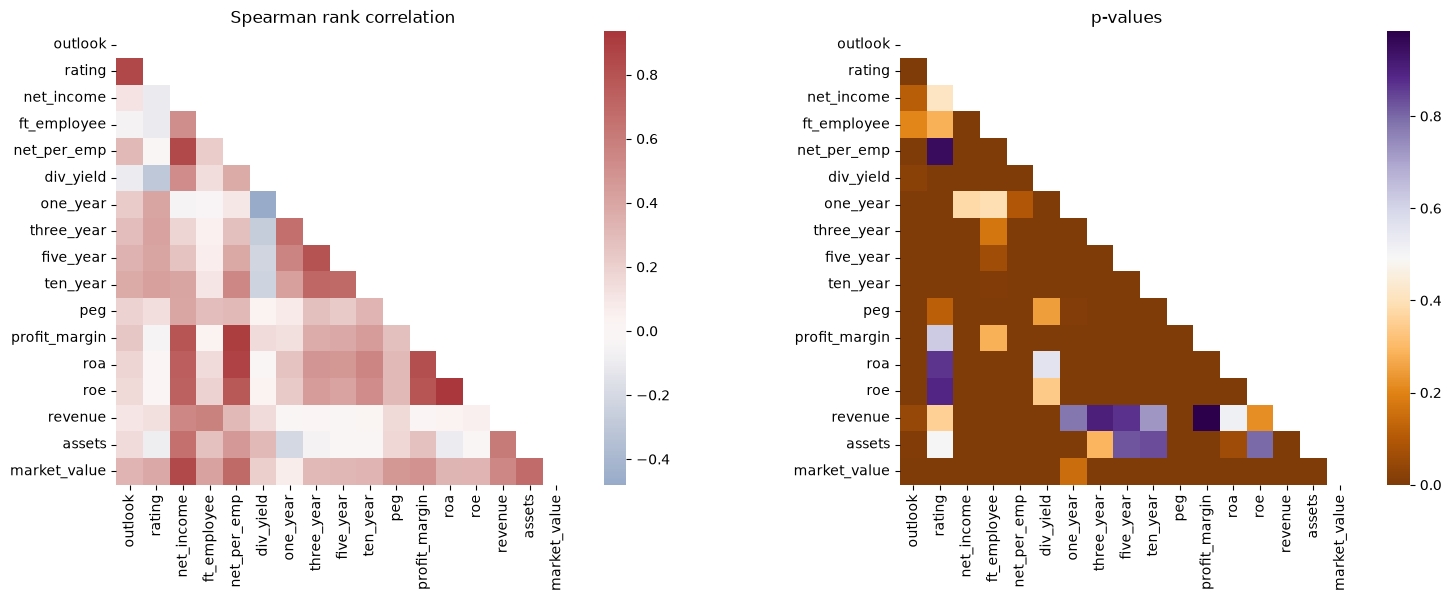

In [5]:
rho, pval = spearman_matrix(analysis)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
mask = np.triu(np.ones_like(rho, dtype=bool))
sns.heatmap(rho, mask=mask, cmap="vlag", center=0, square=True, ax=axes[0])
axes[0].set_title("Spearman rank correlation")
sns.heatmap(pval, mask=mask, cmap="PuOr", square=True, ax=axes[1])
axes[1].set_title("p-values")
plt.tight_layout()
plt.show()

### Pairs that are both significant (p ≤ 0.05) and strong (|ρ| ≥ 0.5)

In [6]:
significant_pairs(rho, pval, alpha=0.05, min_abs_rho=0.5).round(4)

,var_1,var_2,spearman_rho,p_value
0,roa,roe,0.9353,0.0
1,net_per_emp,profit_margin,0.9008,0.0
2,net_per_emp,roa,0.8774,0.0
3,outlook,rating,0.8576,0.0
4,net_income,net_per_emp,0.8517,0.0
5,net_income,market_value,0.8498,0.0
6,profit_margin,roa,0.8207,0.0
7,three_year,five_year,0.8045,0.0
8,profit_margin,roe,0.7910,0.0
9,net_income,profit_margin,0.7877,0.0


## The focused test: outlook vs 5-year ROI

(The original version of this analysis had a bug where the 10-year plot
regressed against the 5-year column — fixed here.)

In [7]:
result_5yr = regression_report(universe["outlook"], universe["five_year"])
print(result_5yr.summary("outlook", "five_year"))

five_year = 0.3354 * outlook + -6.0593
r = 0.2717, r^2 = 0.0738, p-value = 9.998e-11, std_err = 0.0509, n = 548
REJECT the null hypothesis at alpha=0.05: the linear relationship between outlook and five_year is statistically significant.


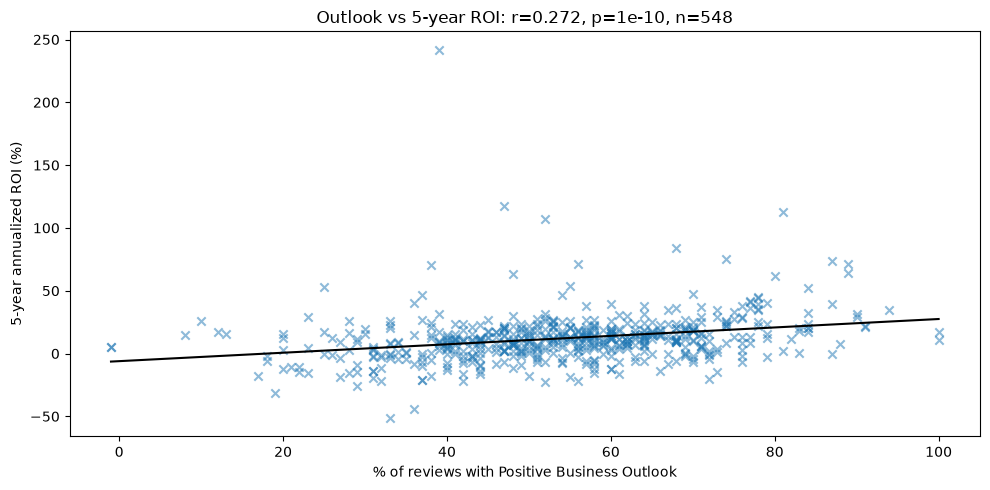

In [8]:
from pathlib import Path
Path("../docs/img").mkdir(parents=True, exist_ok=True)
pair = universe[["outlook", "five_year"]].dropna()
fig, ax = plt.subplots()
ax.scatter(pair["outlook"], pair["five_year"], marker="x", alpha=0.5)
xs = np.linspace(pair["outlook"].min(), pair["outlook"].max(), 100)
ax.plot(xs, result_5yr.slope * xs + result_5yr.intercept, color="black")
ax.set_xlabel("% of reviews with Positive Business Outlook")
ax.set_ylabel("5-year annualized ROI (%)")
ax.set_title(
    f"Outlook vs 5-year ROI: r={result_5yr.r_value:.3f}, "
    f"p={result_5yr.p_value:.2g}, n={result_5yr.n}"
)
plt.tight_layout()
plt.savefig("../docs/img/01_outlook_vs_five_year.png", dpi=120)
plt.show()


In [9]:
result_10yr = regression_report(universe["outlook"], universe["ten_year"])
print(result_10yr.summary("outlook", "ten_year"))

ten_year = 0.2581 * outlook + -2.5745
r = 0.3909, r^2 = 0.1528, p-value = 3.12e-19, std_err = 0.0276, n = 487
REJECT the null hypothesis at alpha=0.05: the linear relationship between outlook and ten_year is statistically significant.


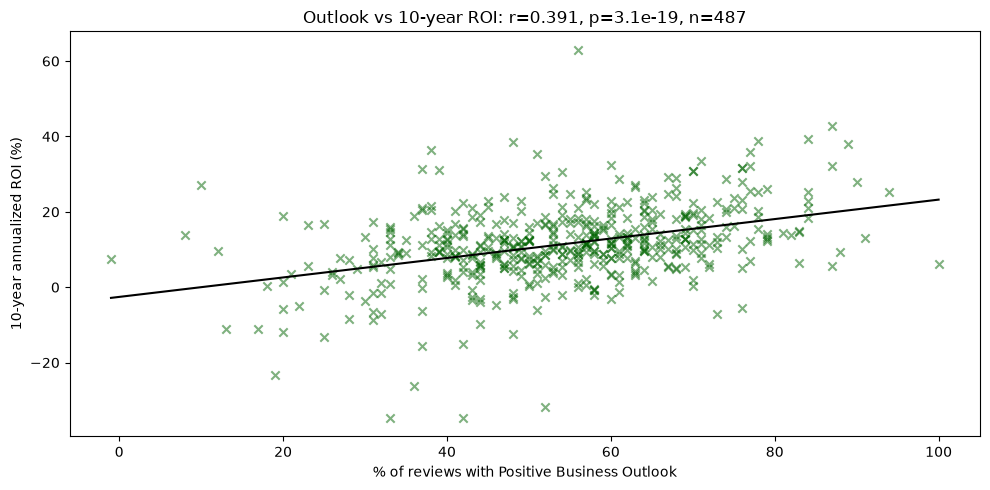

In [10]:
pair10 = universe[["outlook", "ten_year"]].dropna()
fig, ax = plt.subplots()
ax.scatter(pair10["outlook"], pair10["ten_year"], marker="x", alpha=0.5, color="darkgreen")
xs = np.linspace(pair10["outlook"].min(), pair10["outlook"].max(), 100)
ax.plot(xs, result_10yr.slope * xs + result_10yr.intercept, color="black")
ax.set_xlabel("% of reviews with Positive Business Outlook")
ax.set_ylabel("10-year annualized ROI (%)")
ax.set_title(
    f"Outlook vs 10-year ROI: r={result_10yr.r_value:.3f}, "
    f"p={result_10yr.p_value:.2g}, n={result_10yr.n}"
)
plt.tight_layout()
plt.show()

## Multivariate check: does outlook add anything beyond size and payout?

A single-factor regression can flatter a signal that is really proxying for
something else. Here we regress 5-year ROI on outlook plus company
fundamentals with scikit-learn (the original 2020 version of this analysis
used the long-removed `sklearn.cross_validation` module; this is the modern
`model_selection` equivalent) and compare out-of-sample R² with and without
the outlook feature.

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

features = ["outlook", "net_income", "ft_employee", "div_yield", "revenue", "assets", "market_value"]
model_data = universe[features + ["five_year"]].dropna()
print(f"Companies with complete feature rows: {len(model_data)}")

X = model_data[features]
y = model_data["five_year"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler().fit(X_train)


def out_of_sample_r2(columns: list[str]) -> float:
    model = LinearRegression()
    idx = [features.index(c) for c in columns]
    model.fit(scaler.transform(X_train)[:, idx], y_train)
    return model.score(scaler.transform(X_test)[:, idx], y_test)


r2_with = out_of_sample_r2(features)
r2_without = out_of_sample_r2([f for f in features if f != "outlook"])
print(f"Out-of-sample R^2 with outlook   : {r2_with:.4f}")
print(f"Out-of-sample R^2 without outlook: {r2_without:.4f}")
print(f"Marginal contribution of outlook : {r2_with - r2_without:+.4f}")

Companies with complete feature rows: 78
Out-of-sample R^2 with outlook   : 0.2706
Out-of-sample R^2 without outlook: 0.2347
Marginal contribution of outlook : +0.0358


## Verdict

We **reject H₀** at α = 0.05 for both horizons: companies whose employees
report a more positive business outlook have had measurably better long-run
stock returns. But the honest read is that the relationship, while highly
significant statistically (the sample is large), explains only ~7% of the
variance in 5-year ROI. That is exactly the profile of a useful *screening
factor*: it shifts the odds, it does not pick winners by itself.

### Caveats

- **Survivorship bias**: the universe was assembled from companies listed in
  2020; firms that delisted before then are absent.
- **Look-back structure**: outlook was measured in 2018–2020 while the
  returns are trailing, so this is an association study, not a proof that
  outlook *predicts* future returns.
- **Correlation ≠ causation**: good stock performance may cause employee
  optimism rather than reflect information about the future.

These caveats are why notebooks 03–09 move from association to *decision
rules*, and from decision rules to *cost-aware backtests*.